# Mirror reflectivity and transmittance

We plot the amplitudes of the light fields transmitted and reflected by a mirror (given by a single surface). Initially, the mirror has a power reflectance and transmittance of $R = T = 0.5$ and is, thus, lossless. We tune the transmittance from 0.5 to 0. Since we do not explicitly change the reflectivity, R remains at 0.5 and the mirror loss increases instead, which is shown by the trace labelled ‘total’ corresponding to the sum of the reflected and transmitted light power. The plot also shows the phase convention of a 90° phase shift for the transmitted light.

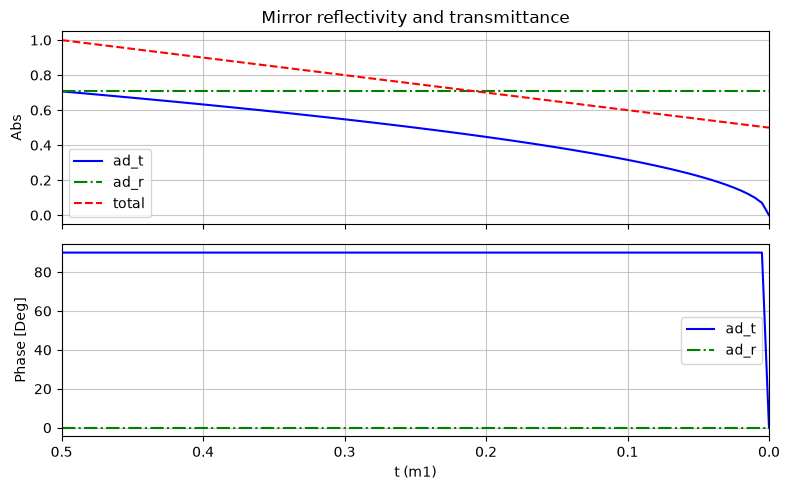

In [11]:
import finesse
from finesse.analysis.actions import Xaxis
import numpy as np
import matplotlib.pyplot as plt

model = finesse.Model()
model.parse("""
l l1 P=1
s s1 l1.p1 m1.p1 L=1

m m1 R=0.5 T=0.5 phi=0

ad ad_t m1.p2.o f=0
ad ad_r m1.p1.o f=0
""")

# scan from 0.5 down to 0
out = model.run(Xaxis("m1.T", "lin", 0.5, 0, 100),
                progress_bar=False)

T     = out.x[0]
ad_t  = np.abs(out['ad_t'])
ad_r  = np.abs(out['ad_r'])
total = ad_r**2 + ad_t**2

phase_t = np.angle(out['ad_t'], deg=True)
phase_r = np.angle(out['ad_r'], deg=True)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 5), sharex=True)

ax1.plot(T, ad_t,  label='ad_t', color='blue',  linewidth=1.5)
ax1.plot(T, ad_r,  label='ad_r', color='green',  linewidth=1.5, linestyle='-.')
ax1.plot(T, total, label='total',   color='red',   linewidth=1.5, linestyle='--')
ax1.set_ylabel('Abs')
ax1.set_title('Mirror reflectivity and transmittance')
ax1.legend()
ax1.grid(True, alpha=0.7)
ax1.set_xlim(0.5, 0)  

ax2.plot(T, phase_t, label='ad_t', color='blue',  linewidth=1.5)
ax2.plot(T, phase_r, label='ad_r', color='green',  linewidth=1.5, linestyle='-.')
ax2.set_ylabel('Phase [Deg]')
ax2.set_xlabel('t (m1)')
ax2.set_xlim(0.5, 0)
ax2.legend()
ax2.grid(True, alpha=0.7)

plt.tight_layout()
plt.show()